In [1]:
import pandas as pd
import numpy as np
import glob
import os
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
#import switch
%load_ext autoreload
%autoreload 2

In [2]:
#seed_dirs="../long_sw_100000_fin/"
seed_dirs="../new_ba_100000/"
sw = pd.read_csv('test_files.csv').values
sw

array([['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0.csv'],
       ['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_1.csv'],
       ['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_2.csv'],
       ...,
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_7.csv'],
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_8.csv'],
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_9.csv']],
      dtype=object)

In [35]:
2400*14

33600

In [34]:
sw[::10].shape

(2400, 1)

In [36]:
%%time
chosen_seeds = sw[::10][::1]
show_fig_flag=False

days = np.arange(14)
row_n = len(chosen_seeds)//2+math.ceil(len(chosen_seeds)%2)
if show_fig_flag:
    fig, ax = plt.subplots(row_n, 2, figsize=(10, row_n*2.5))
    ax = ax.flatten()
else:
    ax=days
    
results = pd.DataFrame([])

for type_start_day, one_ax in zip(days, ax):
    #type_start_day = 1
    beta_prediction_method='real'
    
    if show_fig_flag:
        ax_in_main = [one_ax]
    else:
        ax_in_main = None

    all_rmse_I, all_rmse_Inc, all_rmse_Beta, \
        all_r2, all_r2_Inc, all_r2_full, all_r2_Inc_full,\
        all_peak, execution_time, start_days,df_on_switch = \
            plot_hyb.main_f('seir', count_stoch_line=0, 
                           beta_prediction_method=beta_prediction_method, 
                           type_start_day=type_start_day, seed_numbers=chosen_seeds,
                           show_fig_flag=show_fig_flag, seed_dirs=seed_dirs, 
                           sigma=0.3, gamma=0.2,
                           ax = ax_in_main, model_path='', perc_switch=0.01,
                           is_filename=True, on_incidence=True,
                           switch_on_incidence=False, detailed=True)
    
    sww = pd.Series(chosen_seeds.flatten()).str.split('_',expand=True)
    sww.columns = ['p','beta','sigma','gamma','initi',
               'alpha','seed','nseed']
    sww[['beta','alpha']] = sww[['beta','alpha']].astype(float).round(2)

    # creating a dataframe for peaks
    all_peak = pd.DataFrame(all_peak, 
                    columns=['actual_peak_I', 'predicted_peak_I', 
                            'actual_peak_Inc', 'predicted_peak_inc',
                            'actual_peak_day', 'predicted_peak_day',
                            'actual_peak_day_Inc', 'predicted_peak_day_inc'])
    # creating a dataframe for peaks RMSE, predicted time, start day
    rmse_df = pd.DataFrame({
        'type_start_day': start_days,
        'rmse_I': all_rmse_I,
        'rmse_Inc': all_rmse_Inc,
        'rmse_Beta': all_rmse_Beta,
        'r2': all_r2,
        'r2_Inc': all_r2_Inc,
        'r2_full': all_r2_full,
        'r2_Inc_full': all_r2_Inc_full,
        'time_predict': execution_time,
    })
    df_on_switch = pd.DataFrame(df_on_switch, 
                                columns = ['S','E','I','R','Beta','incidence'])
    seeds_info = pd.concat([sww[['beta','alpha']], 
                            pd.DataFrame(chosen_seeds, columns=['file']), 
                            df_on_switch], axis=1)
    # merging dataframes
    full_one = pd.concat([seeds_info, rmse_df, all_peak], axis=1)
    results = pd.concat([results, full_one], axis=0)
    
results = results.reset_index(drop=True)
print(results.shape)

filtered = results[results.type_start_day<results.actual_peak_day]
filtered[['S','E','I','R','incidence']
        ] = (filtered[['S','E','I','R','incidence']]/100000).round(2)

filtered['days_until_peak_I'] = filtered.actual_peak_day - filtered.type_start_day
filtered['ab'] = (filtered.beta*filtered.alpha).round(3)

print(filtered.shape)
filtered.head()


(33600, 26)
(30131, 28)
CPU times: total: 4min 17s
Wall time: 4min 36s


,beta,alpha,file,S,E,I,R,Beta,incidence,type_start_day,...,actual_peak_I,predicted_peak_I,actual_peak_Inc,predicted_peak_inc,actual_peak_day,predicted_peak_day,actual_peak_day_Inc,predicted_peak_day_inc,days_until_peak_I,ab
0,0.1,0.28,p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0...,0.28,0.0,0.0,0.72,0.000289,0.0,0,...,105,96.0,38.0,31.0,9,6,6,4,9,0.028
1,0.1,0.32,p_0.1_0.3_0.2_0.0001_0.3200000000000001_seed_0...,0.32,0.0,0.0,0.68,0.000341,0.0,0,...,171,147.0,55.0,43.0,10,8,8,5,10,0.032
2,0.1,0.34,p_0.1_0.3_0.2_0.0001_0.34000000000000014_seed_...,0.34,0.0,0.0,0.66,0.000321,0.0,0,...,187,151.0,64.0,41.0,9,9,6,5,9,0.034
3,0.1,0.35,p_0.1_0.3_0.2_0.0001_0.35000000000000014_seed_...,0.35,0.0,0.0,0.65,0.000271,0.0,0,...,186,129.0,56.0,34.0,11,10,5,5,11,0.035
4,0.1,0.37,p_0.1_0.3_0.2_0.0001_0.37000000000000016_seed_...,0.37,0.0,0.0,0.63,0.000308,0.0,0,...,162,127.0,57.0,36.0,7,8,7,5,7,0.037


In [37]:
filtered.columns

Index(['beta', 'alpha', 'file', 'S', 'E', 'I', 'R', 'Beta', 'incidence',
       'type_start_day', 'rmse_I', 'rmse_Inc', 'rmse_Beta', 'r2', 'r2_Inc',
       'r2_full', 'r2_Inc_full', 'time_predict', 'actual_peak_I',
       'predicted_peak_I', 'actual_peak_Inc', 'predicted_peak_inc',
       'actual_peak_day', 'predicted_peak_day', 'actual_peak_day_Inc',
       'predicted_peak_day_inc', 'days_until_peak_I', 'ab'],
      dtype='object')

In [38]:
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator, MultipleLocator

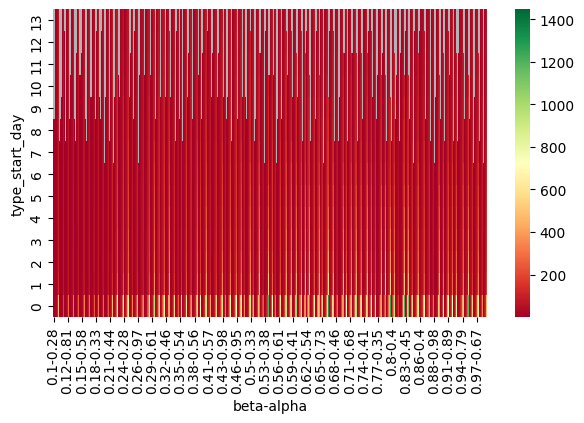

In [39]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot(columns=['beta','alpha'], index='type_start_day', 
                             values='rmse_Inc')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

In [41]:
gg = filtered.groupby(['beta','alpha'])
groupes = gg.groups.keys()
len(list(groupes))

2400

<Axes: >

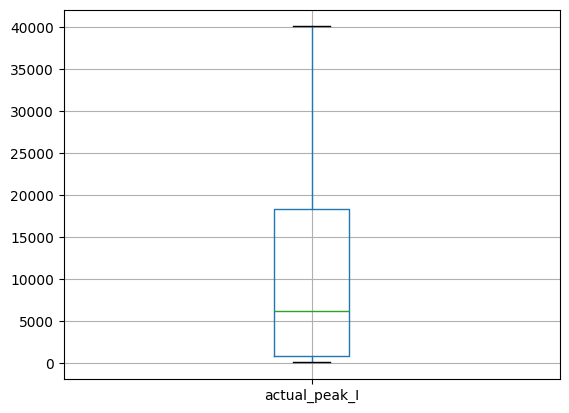

In [42]:
filtered[['actual_peak_I']].boxplot()

In [80]:
gg2 = filtered[filtered.actual_peak_I>=5000].groupby(['beta','alpha'])
groupes2 = gg2.groups.keys()
len(list(groupes2))

1169

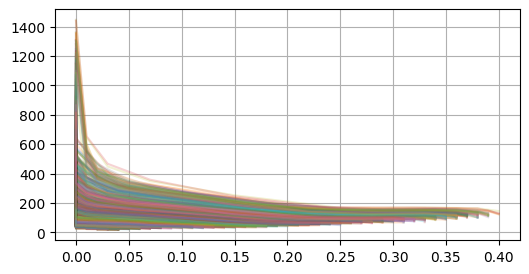

In [81]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()
#plt.ylim(-10,800)

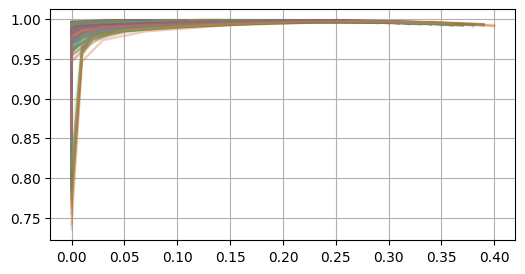

In [82]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.r2_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()

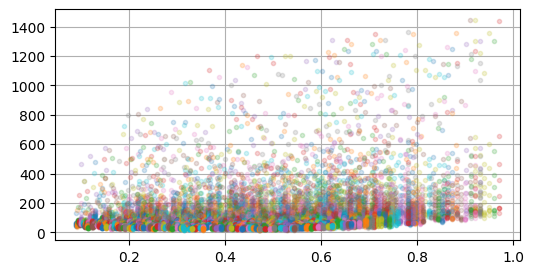

In [83]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.beta*one_group.alpha, one_group.rmse_Inc, 
         marker='.', ls='', alpha=.2)
    
plt.grid()
#plt.ylim(-10,800)

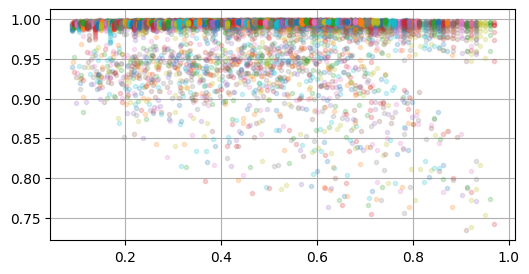

In [84]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.ab, one_group.r2_Inc, 
         marker='.', ls='', alpha=.2)
    
plt.grid()
#plt.ylim(-10,800)

In [85]:
filtered.shape, filtered['ab'].nunique()

((30131, 28), 715)

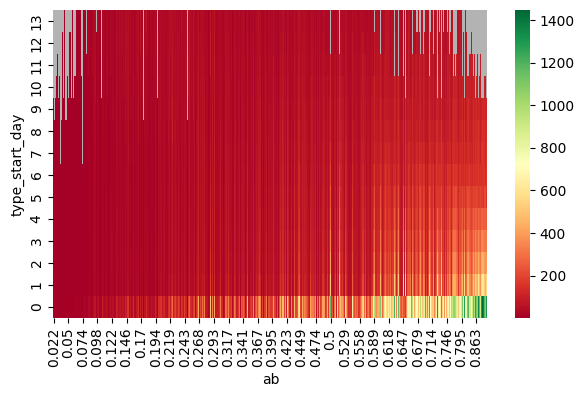

In [86]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot_table(columns='ab', index='type_start_day', 
                             values='rmse_Inc', aggfunc='mean')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

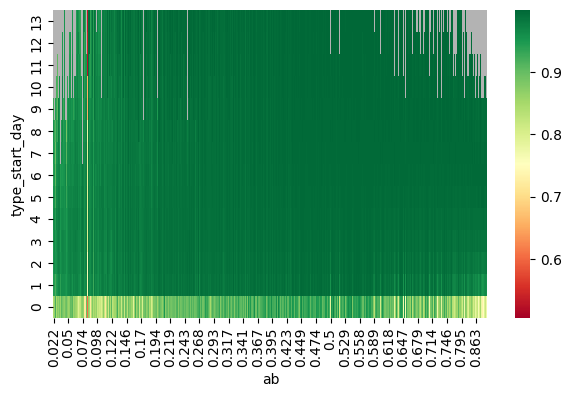

In [87]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot_table(columns='ab', index='type_start_day', 
                             values='r2_Inc', aggfunc='mean')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

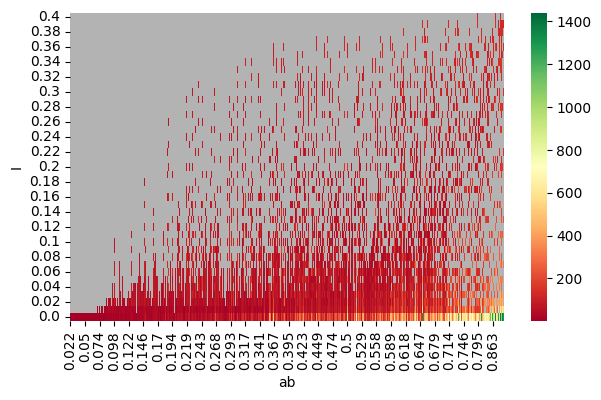

In [88]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot_table(columns='ab', index='I', 
                             values='rmse_Inc', aggfunc='mean')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

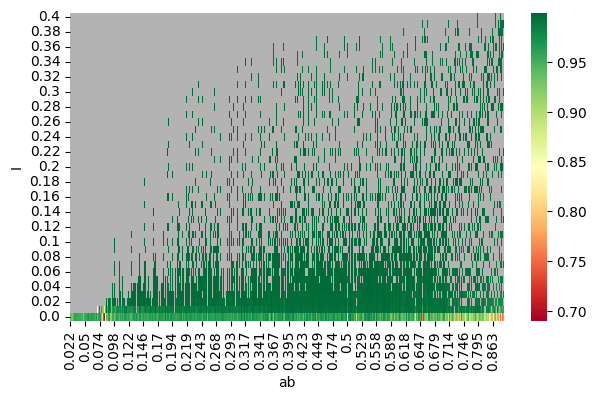

In [89]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot_table(columns='ab', index='I', 
                             values='r2_Inc', aggfunc='mean')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

In [113]:
len(list(groupes2)[::200])

6

In [109]:
mpl.cm.tab10.colors

((0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529))

Видимо, тк (2й сид) и за 2-3 недели хорошо прогноизируем, то раз у 1-го сида пик ближе, то тем более хороший результат.

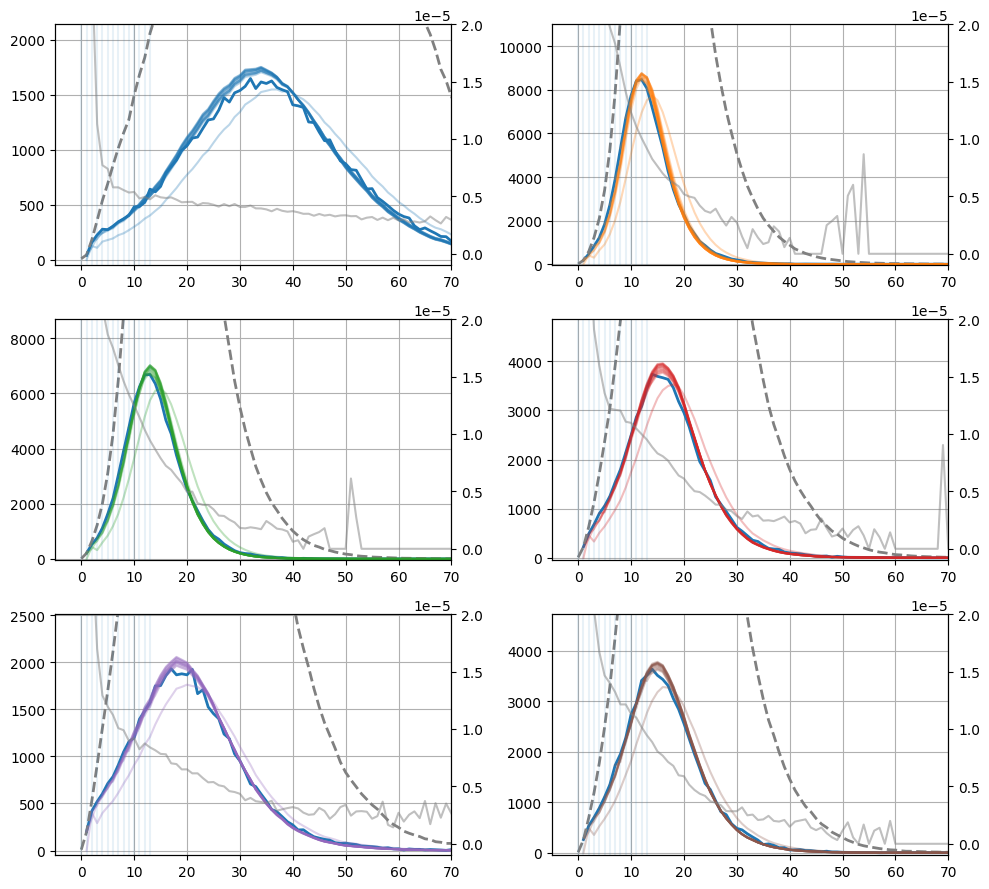

In [123]:
fig, ax = plt.subplots(3, 2, figsize=(10, 9), squeeze=False)
ax = ax.flatten()
sigma, gamma = 0.3,0.2
#brown

for ax0, color, group_id in zip(ax, mpl.cm.tab10.colors, 
                                range(len(list(groupes2)[::200]))):
    group_label = list(groupes2)[::200][group_id]
    beta, alpha = group_label

    filen = gg2.get_group(group_label)['file'].values[0]
    seed_df = pd.read_csv(seed_dirs+filen)

    temp = seed_df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    ax0.plot(seed_df.incidence, lw=2)
    ax0.plot(seed_df.I, lw=2, color='gray', ls='--')
    ax_b = ax0.twinx()
    ax_b.plot(seed_df.Beta, color='gray', alpha=.5)
    
    for i in range(14):
        start_days=[]
        start_day = i
        start_days.append(start_day)
        predicted_days = np.arange(start_day, seed_df.shape[0])
        # choosing the days for prediction
        predicted_days = np.arange(start_day, seed_df.shape[0])

        beggining_beta, predicted_beta, \
                predicted_I = predict_Beta_I.predict_beta(
                                'seir', seed_df,
                                'real', 
                                predicted_days, False, 
                                0, float(sigma), float(gamma),
                                '', '', 4)
        


        predicted_Inc = np.zeros((0+1, 
                                      predicted_days.shape[0]))
        y = seed_df.iloc[predicted_days[0],:4]
        # predict the Infected compartment trajectory
        ss,ee,predicted_I[0],\
            _ = predict_Beta_I.predict_I('seir', y,
                                          predicted_days-start_day,
                                          predicted_beta,
                                          float(sigma), float(gamma), 'det')
        # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
        from_last = seed_df['incidence'].iloc[predicted_days[0]]
        predicted_Inc[0] = np.append(from_last, 
                                   (ee[:-1] - ee[1:]) - \
                                       (ss[1:] - ss[:-1]))
        predicted_Inc[0][predicted_Inc[0]<0] = 0
        
        ax0.plot(predicted_days,predicted_Inc[0], color=color,alpha=.3) 
        ax0.axvline(i, alpha=.1)
        ax0.set_xlim(-5,70)
        
    ax_b.set_ylim(-1e-6,2e-5)
    ax0.grid()
    ax0.set_ylim(-50, seed_df.incidence.max()*1.3)
    
plt.tight_layout()

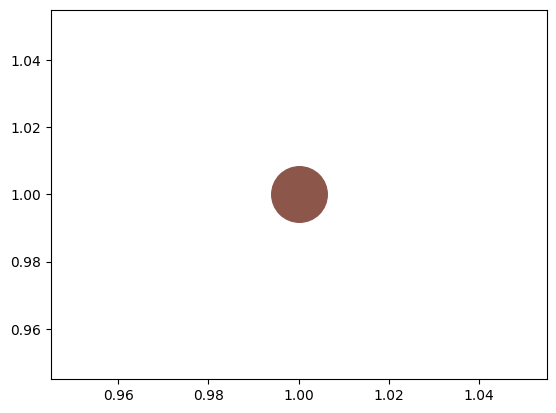

In [138]:
plt.plot(1,1,color=color, marker='o', markersize=40)

133.62443638796012 39
752.1596838437965 16
566.9332764973318 16
265.96056098602287 20
139.04675472660267 22
271.06395924209477 19


(-10.0, 800.0)

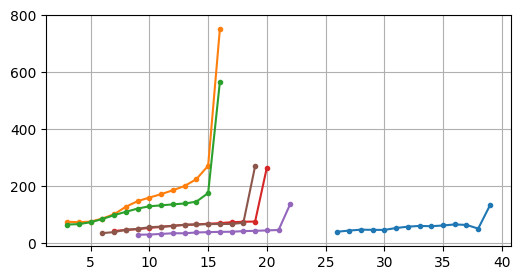

In [100]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::200]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.days_until_peak_I, one_group.rmse_Inc, 
         marker='.', ls='-', alpha=1)
    print(one_group.rmse_Inc.iloc[0], one_group.days_until_peak_I.iloc[0])
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

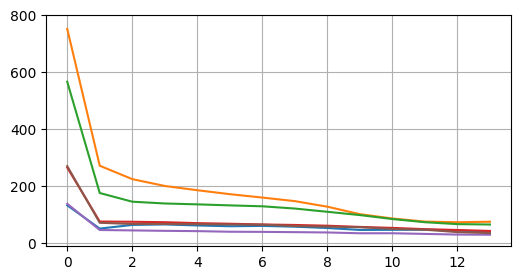

In [92]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::200]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.type_start_day, one_group.rmse_Inc, 
         marker='', ls='-', alpha=1)
    
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

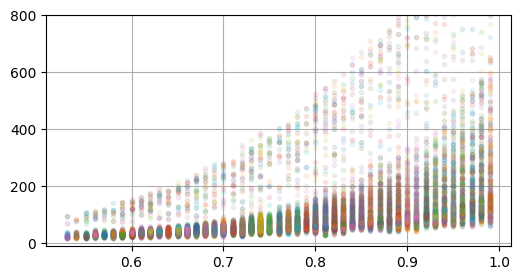

In [142]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.alpha, one_group.rmse_Inc, 
         marker='.', ls='', alpha=.1)
    
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

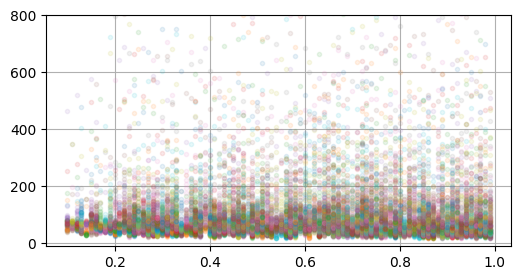

In [143]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.beta, one_group.rmse_Inc, 
         marker='.', ls='', alpha=.1)
    
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

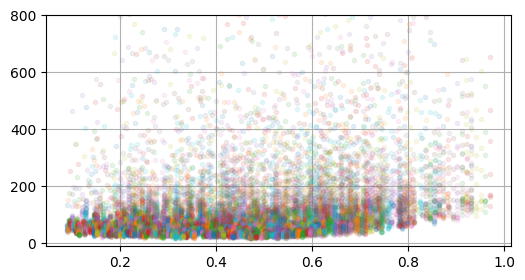

In [144]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.ab, one_group.rmse_Inc, 
         marker='.', ls='', alpha=.1)
    
plt.grid()
plt.ylim(-10,800)

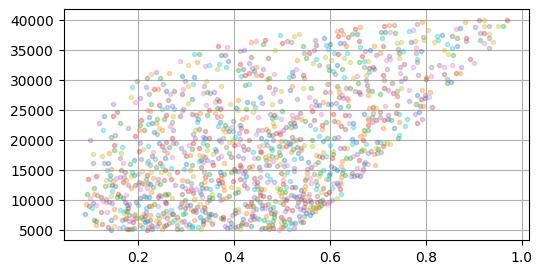

In [152]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.ab.iloc[0], one_group.actual_peak_I.iloc[0], 
         marker='.', ls='', alpha=.3)
    
plt.grid()

(-10.0, 800.0)

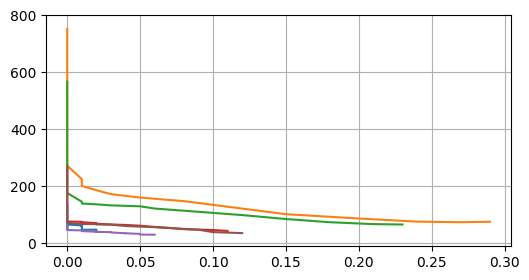

In [127]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::200]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=1)
    
plt.grid()
plt.ylim(-10,800)

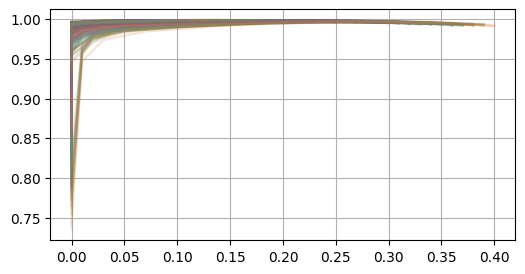

In [129]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.r2_Inc, 
         marker='', ls='-', alpha=.1)
    
plt.grid()
#plt.ylim(-10,800)

Здесь видно, что у одного сида ошибка 15 дней до пика == у другого сида ошибка 5 дней до пика

т.е. разница в ... ??

(-10.0, 800.0)

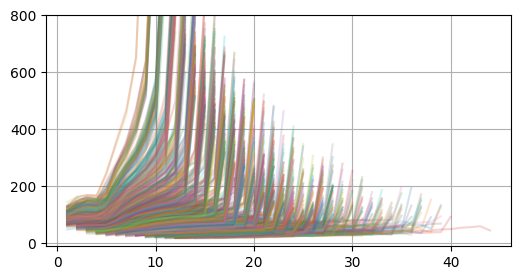

In [93]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.days_until_peak_I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

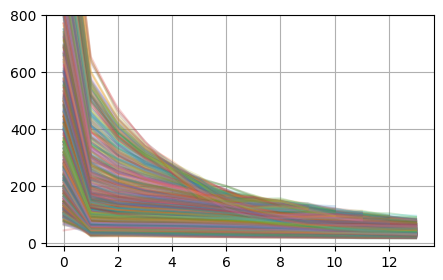

In [95]:
fig, ax = plt.subplots(1,1, figsize=(5,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.type_start_day, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
plt.grid()
plt.ylim(-10,800)

In [102]:
start_day = 5
predicted_days = np.arange(start_day, df.shape[0])

beggining_beta, predicted_beta, \
            predicted_I = predict_Beta_I.predict_beta(
                            I_prediction_method='seir', seed_df=df,
                            beta_prediction_method='last value', 
                            predicted_days=predicted_days, stochastic=False, 
                            count_stoch_line=0, sigma=float(sigma), gamma=float(gamma),
                            window_size=4)
count_stoch_line=0
predicted_Inc = np.zeros((count_stoch_line+1, 
                                  predicted_days.shape[0]))

# use predicted Beta values for predicting I
# extract compartment values on the switch day
y = seed_df.iloc[predicted_days[0],:4]
# predict the Infected compartment trajectory

ss,ee,predicted_I[0],\
    _ = predict_Beta_I.predict_I(I_prediction_method, y,
                                  predicted_days-start_day,
                                  predicted_beta,
                                  sigma, gamma, 'det')
# Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
if on_incidence:
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    from_last = seed_df['incidence'].iloc[predicted_days[0]]
    predicted_Inc[0] = np.append(from_last, 
                               (ee[:-1] - ee[1:]) - \
                                   (ss[1:] - ss[:-1]))
    predicted_Inc[0][predicted_Inc[0]<0] = 0

In [103]:
predicted_Inc

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.]])

In [99]:
beggining_beta, predicted_beta

(array([], dtype=float64),
 array([1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-0

In [12]:
one_seed = X_train_all['file'].values.flatten()[10]